In [2]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/hsc_bands_clean.csv")

# CSV forgot the categorical ordering — re-apply it (one line, as promised):
band_order = ["1", "2", "3", "4", "5", "6", "E1", "E2", "E3", "E4"]
df["band"] = pd.Categorical(df["band"], categories=band_order, ordered=True)

df.head()

,band,percentage,candidature,year,course_name,course_code,band_scale,count
0,6,7.16,18712,2021,Biology,15030,1-6,1340
1,5,24.14,18712,2021,Biology,15030,1-6,4517
2,4,34.79,18712,2021,Biology,15030,1-6,6510
3,3,25.15,18712,2021,Biology,15030,1-6,4706
4,2,6.68,18712,2021,Biology,15030,1-6,1250


In [4]:
# TODO: keep only rows where band is the top of its scale ("6" or "E4")
#   hint: df[df["band"].isin(["6", "E4"])]
top = df[df["band"].isin(["6","E4"])]
top

,band,percentage,candidature,year,course_name,course_code,band_scale,count
0,6,7.16,18712,2021,Biology,15030,1-6,1340
6,6,10.96,9885,2021,Chemistry,15050,1-6,1083
12,6,16.30,24412,2021,English Advanced,15140,1-6,3979
18,6,0.59,31343,2021,English Standard,15130,1-6,185
24,6,14.79,10694,2021,Legal Studies,15220,1-6,1582
30,6,23.24,16770,2021,Mathematics Advanced,15255,1-6,3897
36,E4,37.26,8547,2021,Mathematics Extension 1,15250,E1-E4,3185
40,E4,42.81,3193,2021,Mathematics Extension 2,15260,E1-E4,1367
44,6,12.42,7922,2021,Physics,15330,1-6,984
50,6,6.35,18893,2022,Biology,15030,1-6,1200


In [5]:
# TODO: average top-band percentage per subject, sorted
#   hint: top.groupby("course_name")["percentage"].mean().sort_values()
top_by_subject = top.groupby("course_name")["percentage"].mean().sort_values()
top_by_subject

course_name
English Standard            0.486
Biology                     7.186
Chemistry                  11.040
Physics                    12.562
English Advanced           14.636
Legal Studies              14.842
Mathematics Advanced       22.730
Mathematics Extension 1    35.192
Mathematics Extension 2    40.382
Name: percentage, dtype: float64

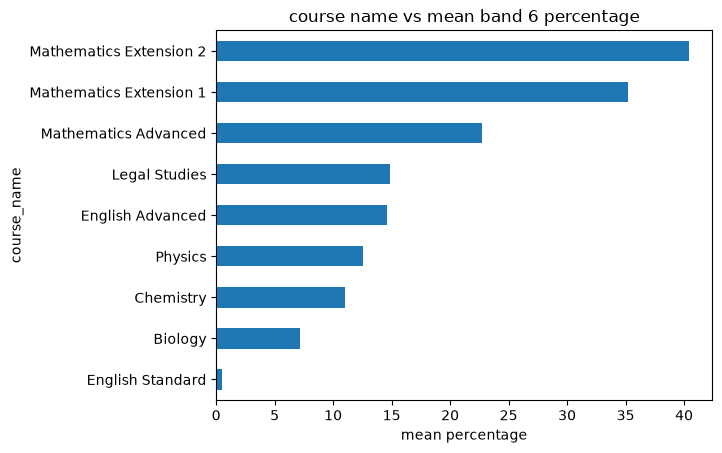

In [6]:
top_by_subject.plot(kind="barh")
# TODO: add an x-axis label and a title — a chart without labels is unreadable
#   plt.xlabel(...) ; plt.title(...)
plt.xlabel("mean percentage")
plt.title("course name vs mean band 6 percentage")
plt.show()

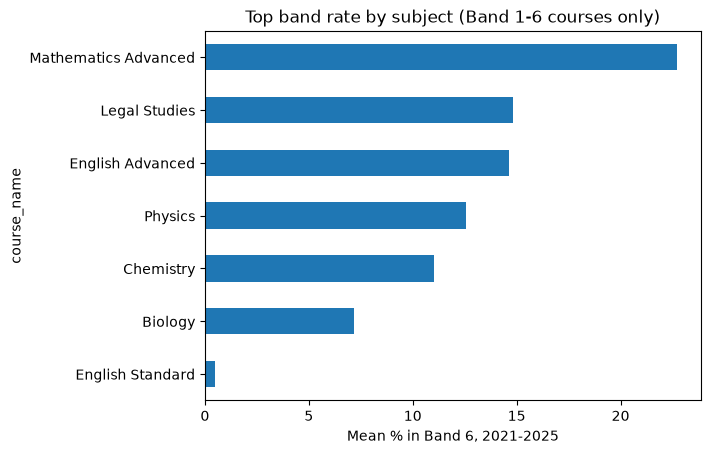

In [7]:
regular = top[top["band_scale"] == "1-6"]
regular.groupby("course_name")["percentage"].mean().sort_values().plot(kind="barh")
plt.xlabel("Mean % in Band 6, 2021-2025")
plt.title("Top band rate by subject (Band 1-6 courses only)")
plt.show()

In [45]:
subject = "Physics"
sub = df[df["course_name"] == subject]

In [46]:
# TODO: pivot sub so rows=year, columns=band, cells=percentage
#   hint: sub.pivot(index="year", columns="band", values="percentage")
pivot = sub.pivot(index="year", columns="band", values="percentage")
pivot

band,6,5,4,3,2,1
year,,,,,,
2021,12.42,28.19,30.71,19.51,7.39,1.75
2022,12.35,29.09,26.54,18.76,9.28,3.95
2023,13.10,25.84,28.56,21.60,9.81,1.09
2024,12.40,25.92,26.80,21.01,11.00,2.86
2025,12.54,25.19,25.75,21.21,13.81,1.50


In [47]:
pivot = pivot.dropna(axis=1, how="all")     # remove all-NaN columns

In [48]:
pivot

band,6,5,4,3,2,1
year,,,,,,
2021,12.42,28.19,30.71,19.51,7.39,1.75
2022,12.35,29.09,26.54,18.76,9.28,3.95
2023,13.10,25.84,28.56,21.60,9.81,1.09
2024,12.40,25.92,26.80,21.01,11.00,2.86
2025,12.54,25.19,25.75,21.21,13.81,1.50


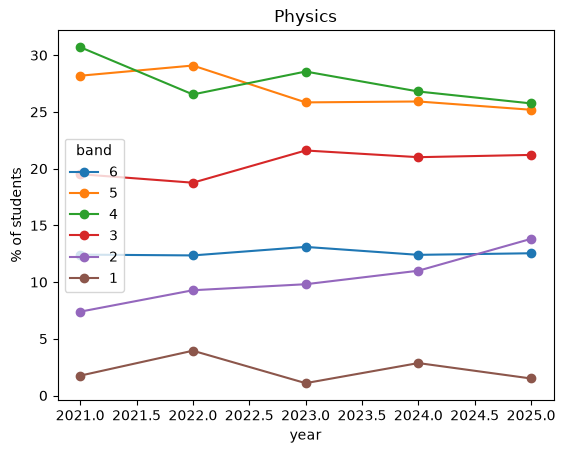

In [49]:
pivot.plot(marker="o")
# TODO: add ylabel ("% of students") and a title with the subject name
plt.ylabel("% of students")
plt.title(subject)
plt.show()

In [50]:
# TODO: get a single candidature value per (course_name, year)
#   hint: df.groupby(["course_name", "year"])["candidature"].first().reset_index()
#   (all 6 rows are identical, so .first() just picks that value)
enrol = df.groupby(["course_name", "year"])["candidature"].first().reset_index()
enrol

,course_name,year,candidature
0,Biology,2021,18712
1,Biology,2022,18893
2,Biology,2023,19383
3,Biology,2024,19046
4,Biology,2025,20710
5,Chemistry,2021,9885
6,Chemistry,2022,9930
7,Chemistry,2023,9892
8,Chemistry,2024,9722
9,Chemistry,2025,10369


In [51]:
# TODO: pivot enrol so rows=year, columns=course_name, values=candidature
#   hint: enrol.pivot(index="year", columns="course_name", values="candidature")
enrol_wide = enrol.pivot(index="year", columns="course_name", values="candidature")
enrol_wide

course_name,Biology,Chemistry,English Advanced,English Standard,Legal Studies,Mathematics Advanced,Mathematics Extension 1,Mathematics Extension 2,Physics
year,,,,,,,,,
2021,18712,9885,24412,31343,10694,16770,8547,3193,7922
2022,18893,9930,24661,30646,10225,16867,8680,3271,7633
2023,19383,9892,25102,31697,10244,16428,8390,3273,7921
2024,19046,9722,25398,32994,10210,16561,8846,3544,8215
2025,20710,10369,26293,33653,10080,16809,9279,3844,8817


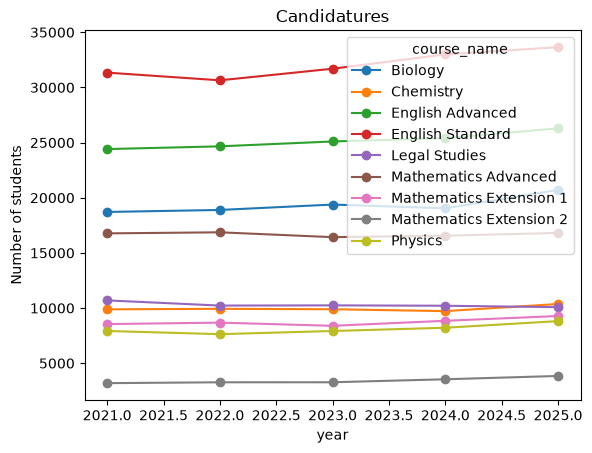

In [52]:
enrol_wide.plot(marker="o")
# TODO: ylabel ("Number of students") and a title
plt.ylabel("Number of students")
plt.title("Candidatures")
plt.show()

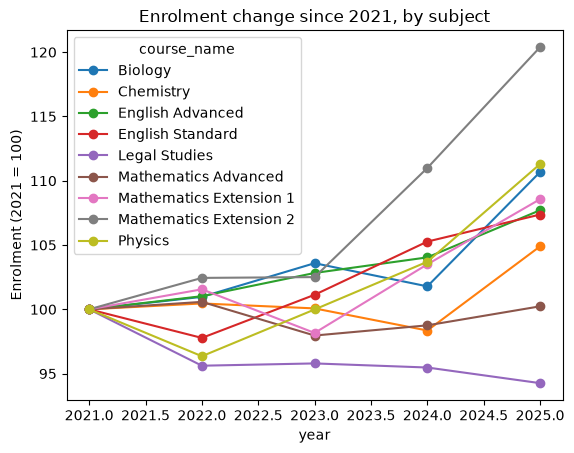

In [53]:
indexed = enrol_wide / enrol_wide.loc[2021] * 100
indexed.plot(marker="o")
plt.ylabel("Enrolment (2021 = 100)")
plt.title("Enrolment change since 2021, by subject")
plt.show()